In [1]:
%load_ext autoreload
%autoreload 2
import sys
from datetime import datetime
from ptflops import get_model_complexity_info
from torch.optim import Adam

sys.path.append("..")
from src import *

sns.set_theme("paper", font_scale=2.5)

In [2]:
df_x, df_y = read_dataset(stage='original')
# df_x['np/ng'] = df_x['np'] / df_x['ng']
df_x.drop(inplace=True, columns=['ias', 'oat'])
df_x['trq_margin'] = df_y['trq_margin']
df_x['domain'] = (df_x['np'] / df_x['ng'] < 1).astype(int) + 1

In [3]:
def get_title(model, domains, epochs, times, lr, is_file=False):
    additional = f'grid={model.grid_size}' if type(model) in [PyKAN, EfficientKAN] else ''
    return f'{model.__class__.__name__}_layers=[{"-".join(map(str, model.layers))}]_epochs={epochs}_times={times}_lr={lr}_{additional}_{datetime.now().ctime().replace(":", "-")}' if is_file else f'{model.__class__.__name__} Epochs={epochs} Times={times} Lr={lr}'

In [4]:
def idl_train(model: PHMNetwork, domains: list[int], epochs: int, times: int, lr=1e-3, device='cpu', silent=True) -> \
        tuple[
            list, list, list]:
    model.reset()
    train_losses, valid_losses, test_metrics = [], [], []
    optimizer = Adam(model.parameters(), lr=lr)
    trainset, validset, testset, _ = split_dataset(df_x, df_y['faulty'], 0.5, standardize_y=False,
                                                   group_by='domain', device=device, seed=0)
    for i, domain in enumerate(tqdm(domains * times)):
        min_length = min(trainset[1][0].shape[0], trainset[2][0].shape[0])
        for d in domains:
            trainset[d] = (trainset[d][0][:min_length], trainset[d][1][:min_length])

        def test():
            metrics = model.test(testset, batch_size=2048, silent=silent)
            test_metrics[i].append(metrics)

        test_metrics.append([])
        train_loss, valid_loss = (
            model.fit(trainset[domain], validset[domain], optimizer, epochs=epochs,
                      batch_size=2048, callback=test, silent=silent))
        train_losses.append(train_loss)
        valid_losses.append(valid_loss)
        # model.save(f'IDL_{model.__class__.__name__}_{domain}')

    # Save to file
    with open(f'results/idl/{get_title(model, domains, epochs, times, lr, is_file=True)}', 'wb') as f:
        pickle.dump((train_losses, valid_losses, test_metrics), f)
    return train_losses, valid_losses, test_metrics

In [5]:
USE_NATIVE_LOSS = True
DOMAINS = [1, 2]
EPOCHS = 5
TIMES = 5
LR = 2e-2

## Finding a matching shape for KAN and MLP with `ptflops`

In [12]:
kan_shape = (len(df_x.columns) - 1, 51, 51, 1)
mlp_shape = (len(df_x.columns) - 1, 256, 256, 1)

effKAN = EfficientKAN([*kan_shape], "classification", grid_size=20, continual_learning=True)
mlp = MLP([*mlp_shape], "classification")

for net in [effKAN, mlp]:
    flops, params = get_model_complexity_info(
        net, (len(df_x.columns) - 1,), as_strings=True, print_per_layer_stat=False
    )
    print(f"[{net.__class__.__name__}] FLOPs: {flops} | Params: {params}")

[EfficientKAN] FLOPs: 108 Mac | Params: 68.03 k
[MLP] FLOPs: 67.84 KMac | Params: 67.84 k


# KAN

In [ ]:
effKAN = EfficientKAN([len(df_x.columns) - 1, 51, 51, 1], 'classification', grid_size=20,
                    use_native_loss=USE_NATIVE_LOSS, continual_learning=True, device='cuda')
idl_train(effKAN, DOMAINS, epochs=EPOCHS, times=TIMES, lr=LR, device='cuda')

  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
times = pd.DataFrame(columns=['size', 'MLP', 'EfficientKAN'])

In [36]:
int(256 / (8**0.5))

90

In [95]:
for size in [2**-8, 2**-7, 2**-6, 2**-5, 2**-4, 2**-3, 2**-2, 2**-1, 1][::-1]:
    start = time_ns()
    mlp = MLP(
        [len(df_x.columns) - 1, int(256 / (size**0.5)), int(256 / (size**0.5)), 1],
        "classification",
        use_native_loss=USE_NATIVE_LOSS,
        device="cuda",
    )
    effKAN = EfficientKAN(
        [len(df_x.columns) - 1, int(51 / (size**0.5)), int(51 / (size**0.5)), 1],
        "classification",
        grid_size=20,
        use_native_loss=USE_NATIVE_LOSS,
        continual_learning=True,
        device="cuda",
    )

    idl_train(mlp, DOMAINS, epochs=4, times=1, lr=LR, device="cuda")
    mlp_end = time_ns()

    idl_train(effKAN, DOMAINS, epochs=4, times=1, lr=LR, device="cuda")
    effkan_end = time_ns()

    times.loc[len(times)] = {
        "size": size,
        "MLP": mlp_end - start,
        "EfficientKAN": effkan_end - mlp_end,
    }

100%|██████████| 2/2 [05:19<00:00, 159.71s/it]


In [96]:
df = times.sort_values("size").head(10)
df.index = (256 / (df["size"] ** 0.5)).astype(np.int32)
df.index = 7 * df.index + (df.index + 1) * df.index + (df.index + 1)
df.index.name = "params"
df

,size,MLP,EfficientKAN
params,,,
8412881,0.007812,7819517577,320464579609
4212737,0.015625,4366682183,197300946704
2109737,0.031250,3133794868,117916704400
1057793,0.062500,2179899563,79743848696
530693,0.125000,2372672931,51583904801
266753,0.250000,1678388798,33170178556
134303,0.500000,2728889997,23539841489
67841,1.000000,2006573714,14377205449
34391,2.000000,2650162455,10883248184


Text(0, 0.5, 'Epoch duration (sec)')

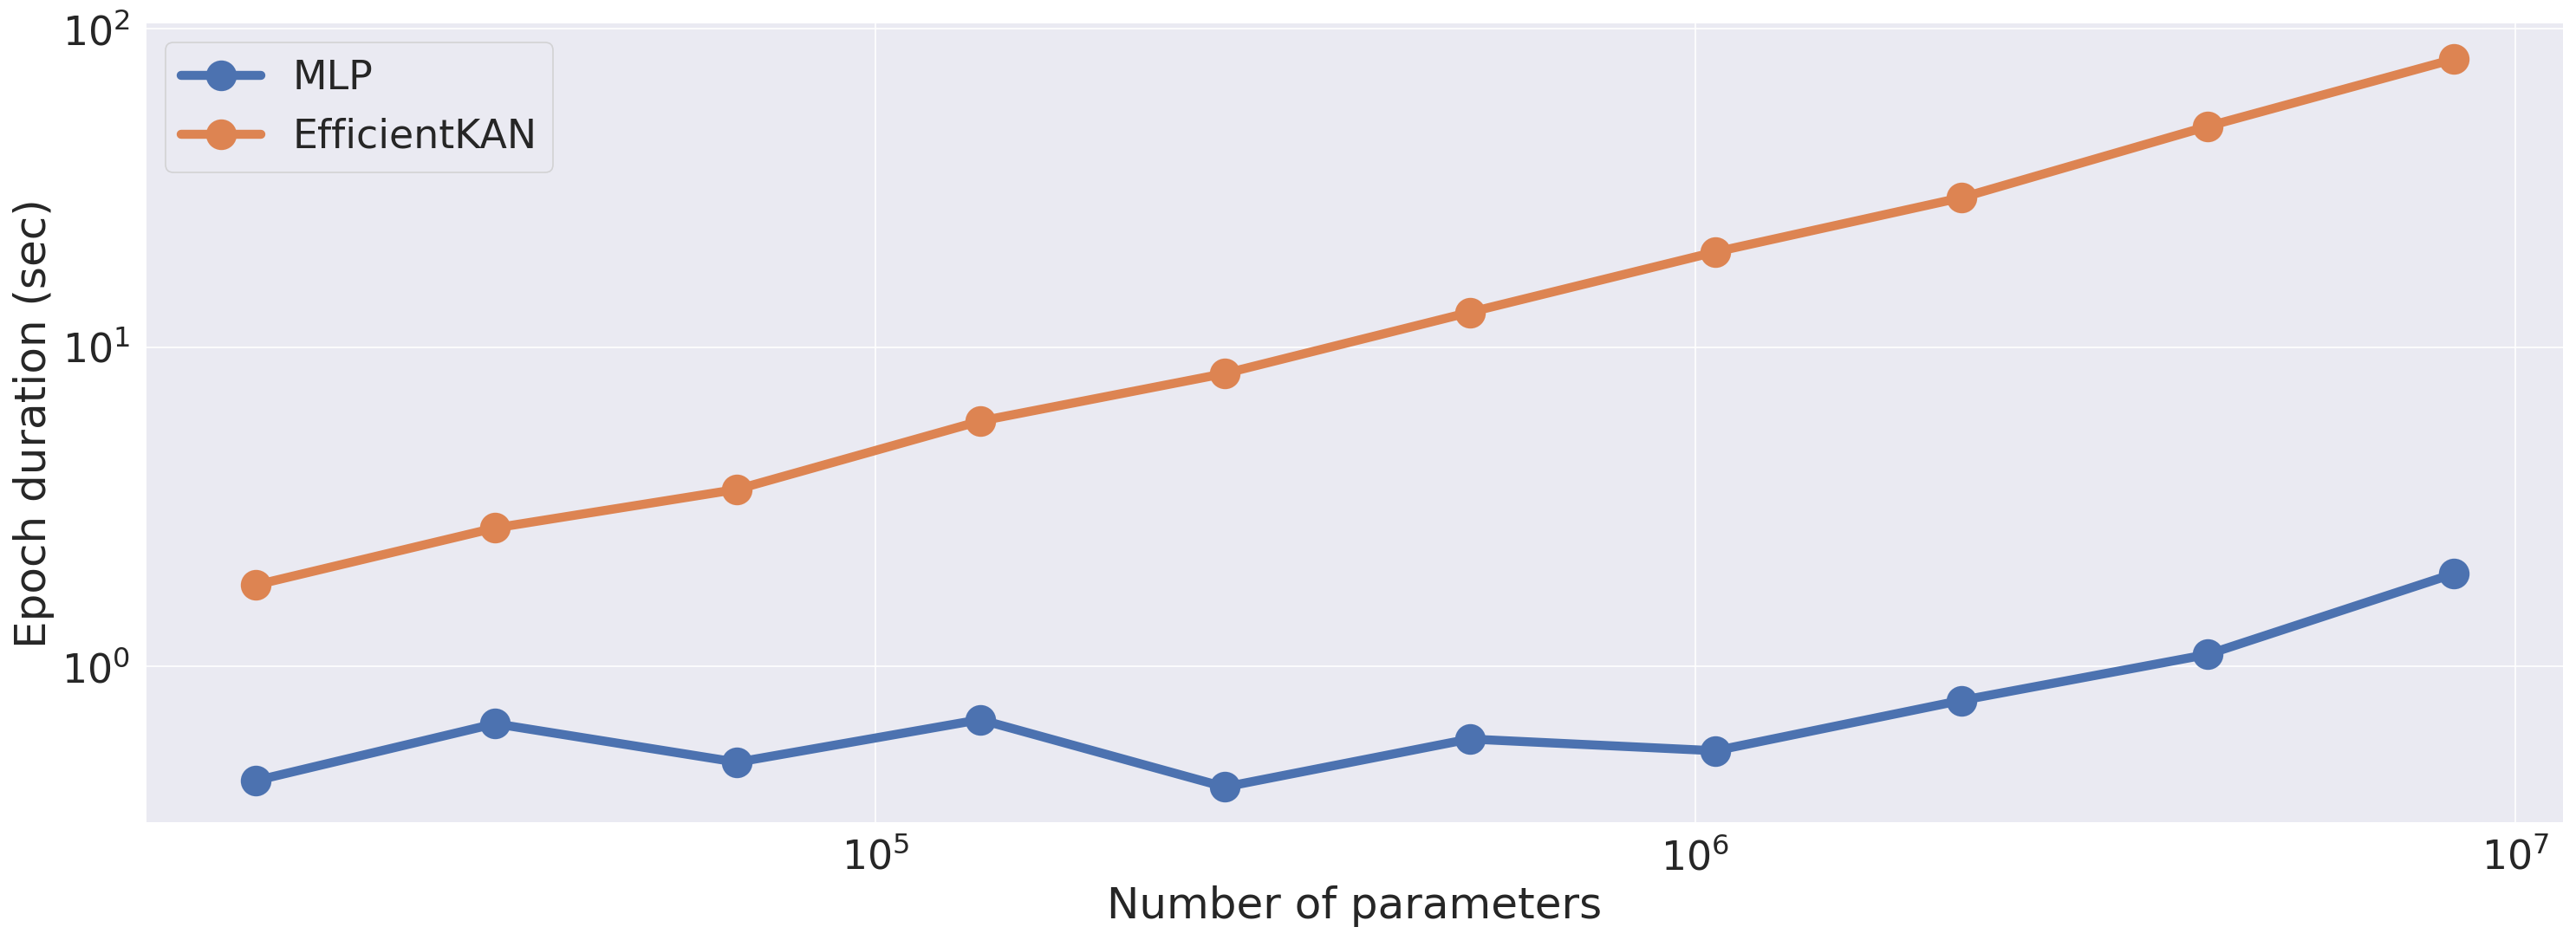

In [97]:
_, ax = plt.subplots(figsize=(24, 8), dpi=150)
(df[["MLP", "EfficientKAN"]] / 1e9 / 4).plot(
    marker="o",
    markersize=16,
    linewidth=5,
    ax=ax,
)
plt.yscale("log")
plt.xscale("log")
plt.xlabel("Number of parameters")
plt.ylabel("Epoch duration (sec)")

In [ ]:
import time
times = {}
for size in [1, 2, 4, 8, 16, 32]:
    start = time.time_ns()
    effKAN = EfficientKAN([len(df_x.columns) - 1, size, size, 1], 'classification', grid_size=20,
                          use_native_loss=USE_NATIVE_LOSS, continual_learning=True, device='cuda')
    idl_train(effKAN, DOMAINS, epochs=1, times=1, lr=LR, device='cuda')
    times[size] = time.time_ns()-start
times

<AxesSubplot:>

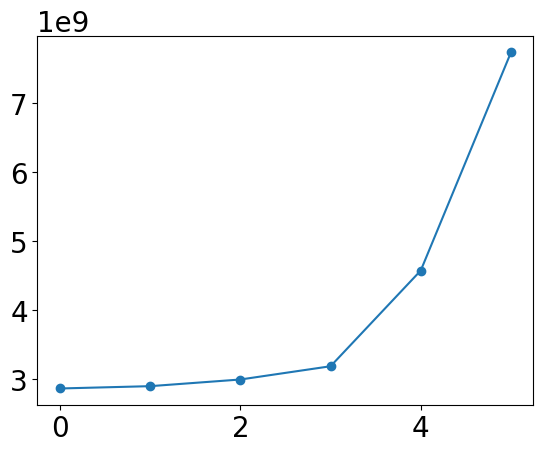

In [ ]:
pd.Series(times.values()).plot(marker='o')

# MLP

In [ ]:
mlp = MLP([len(df_x.columns) - 1, 4, 4, 1], 'classification',
        use_native_loss=USE_NATIVE_LOSS, device='cuda')
idl_train(mlp, DOMAINS, epochs=EPOCHS, times=TIMES, lr=LR, device='cuda')

In [ ]:
for h in [4, 64, 128, 256, 512]:
    mlp = MLP([len(df_x.columns) - 1, h, h, 1], "classification", use_native_loss=USE_NATIVE_LOSS, device="cuda")
    idl_train(mlp, DOMAINS, epochs=EPOCHS, times=TIMES, lr=LR, device="cuda")

100%|██████████| 10/10 [00:11<00:00,  1.11s/it]


# Visualize the results with the visualizer GUI

In [ ]:
TITLES = [
    "Comparison of different KAN grid sizes",
    "Comparison of different MLP architecture sizes",
    "MLP vs KAN without Replay (DIL)",
    "MLP vs KAN with Replay (DIL)",
]
continual_learning_gui(
    results_dir=Path("results/idl/").absolute(),
    metric="avg_test_score",
    ylim=[-0.2, 1],
    title=TITLES[2],
)